In [ ]:
# Connect to SQL Server
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# Load the dataset
df = pd.read_csv("Data/netflix1.csv")
# Display the first 5 rows
print(df.head())

 

  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States  9/25/2021          2020  PG-13    90 min   
1         France  9/24/2021          2021  TV-MA  1 Season   
2  United States  9/24/2021          2021  TV-MA  1 Season   
3         Brazil  9/22/2021          2021  TV-PG    91 min   
4  United States  9/24/2021          1993  TV-MA   125 min   

                                           listed_in  
0                                      Documentaries  
1  Crime TV Shows, International TV Shows, TV Act...  
2                 TV Dr

In [34]:
# Display dataset information
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   str           
 1   type          8790 non-null   str           
 2   title         8790 non-null   str           
 3   director      8790 non-null   str           
 4   country       8790 non-null   str           
 5   date_added    8790 non-null   datetime64[us]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   str           
 8   duration      8790 non-null   str           
 9   listed_in     8790 non-null   str           
dtypes: datetime64[us](1), int64(1), str(8)
memory usage: 686.8 KB
None


In [17]:
# Check dataset shape
print("Shape of dataset:", df.shape)

# Check column names
print("Columns:")
print(df.columns)

Shape of dataset: (8790, 10)
Columns:
Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='str')


In [18]:
# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()


Missing values:
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

Duplicate rows: 0


In [19]:
# Summary statistics
print("\nSummary Statistics:")
print(df.describe(include='all'))

# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()


Summary Statistics:
       show_id   type  title   director        country date_added  \
count     8790   8790   8790       8790           8790       8790   
unique    8790      2   8787       4528             86       1713   
top         s1  Movie  9-Feb  Not Given  United States   1/1/2020   
freq         1   6126      2       2588           3240        110   
mean       NaN    NaN    NaN        NaN            NaN        NaN   
std        NaN    NaN    NaN        NaN            NaN        NaN   
min        NaN    NaN    NaN        NaN            NaN        NaN   
25%        NaN    NaN    NaN        NaN            NaN        NaN   
50%        NaN    NaN    NaN        NaN            NaN        NaN   
75%        NaN    NaN    NaN        NaN            NaN        NaN   
max        NaN    NaN    NaN        NaN            NaN        NaN   

        release_year rating  duration                     listed_in  
count    8790.000000   8790      8790                          8790  
unique    

In [37]:
# Fill missing values
df['director'] = df['director'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna("Not Rated")
df['duration'] = df['duration'].fillna("Unknown")

# Remove rows where date_added is missing
df = df.dropna(subset=['date_added'])

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'])
# Create new columns
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())



Missing values after cleaning:
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
year_added      0
month_added     0
dtype: int64



Data cleaning completed successfully!


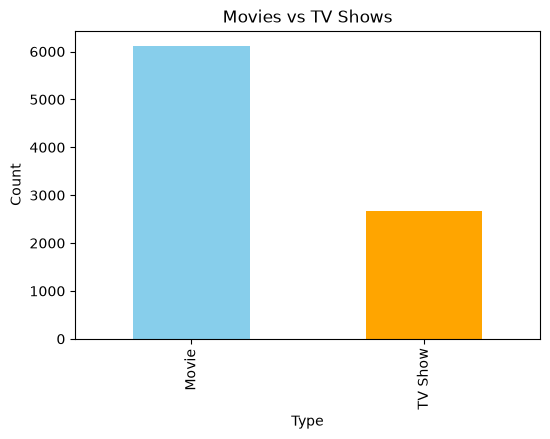

In [31]:
# Save cleaned dataset
df.to_csv("cleaned_netflix.csv", index=False)

print("\nData cleaning completed successfully!")

plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar', color=['skyblue', 'orange'])
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

 

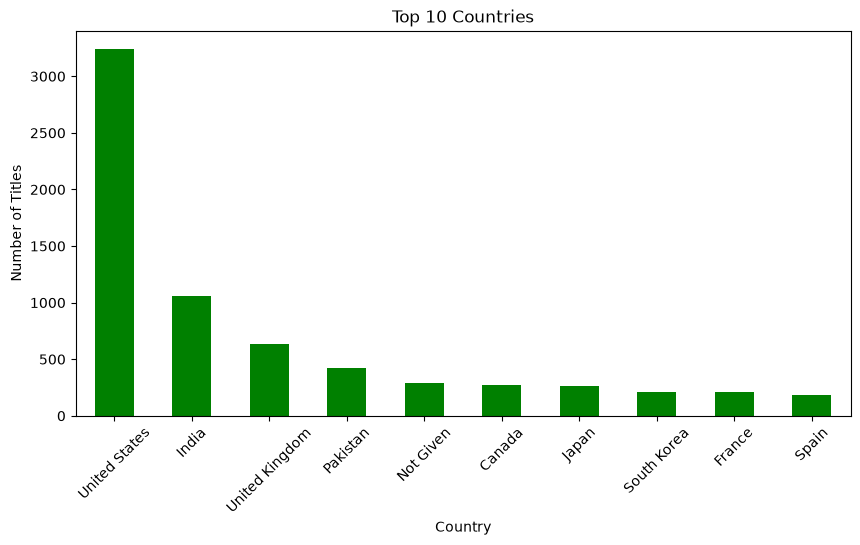

In [30]:
plt.figure(figsize=(10,5))
df['country'].value_counts().head(10).plot(kind='bar', color='green')
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()


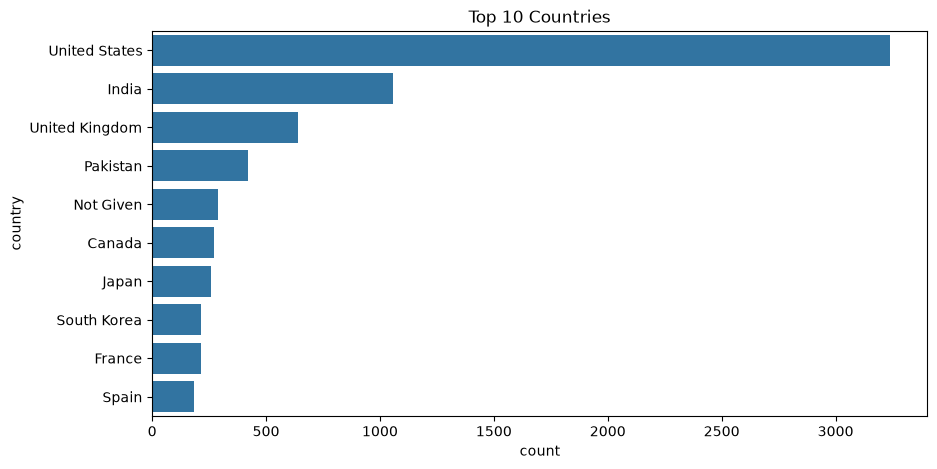

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='country', order=df['country'].value_counts().index[:10])
plt.title("Top 10 Countries")
plt.show()

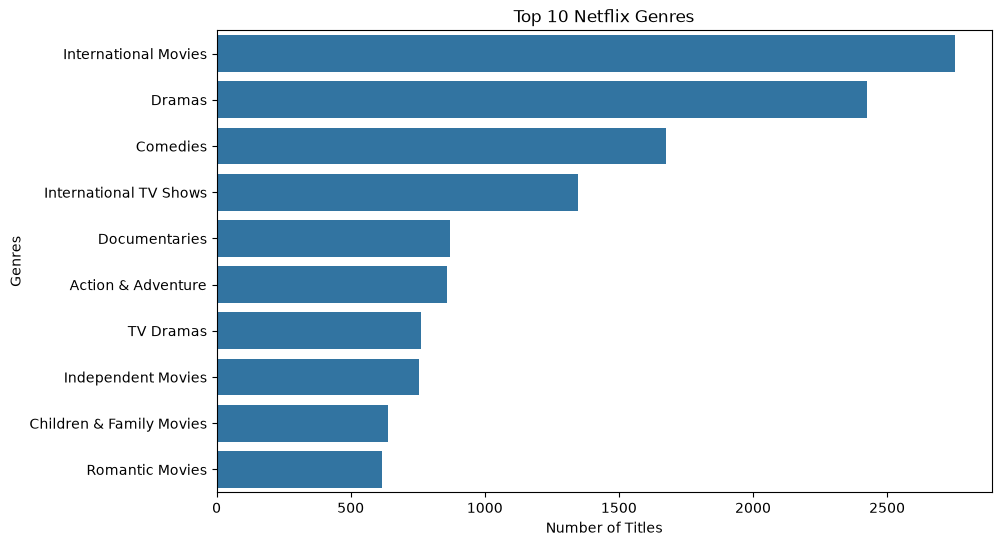

In [28]:
# Split multiple genres into separate rows
genre = df['listed_in'].str.split(', ').explode()

# Count top 10 genres
top_genres = genre.value_counts().head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genres")

plt.show()

 

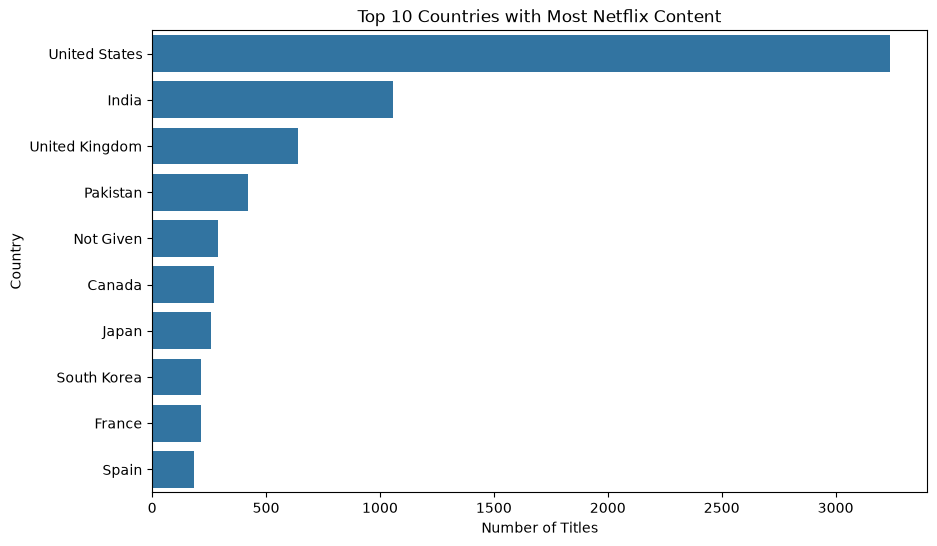

In [25]:
# Country Analysis

country = df['country'].str.split(', ').explode()

top_countries = country.value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Countries with Most Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()
 

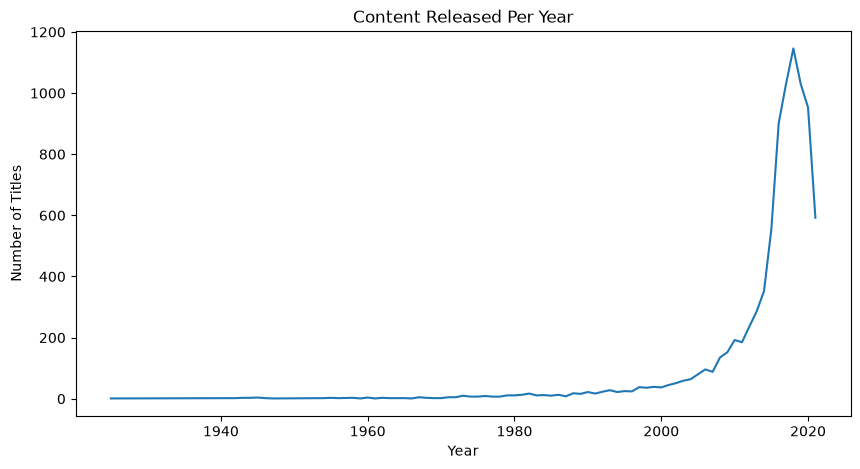

In [ ]:
# Content Released Per Year
plt.figure(figsize=(10,5))
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

import matplotlib.pyplot as plt

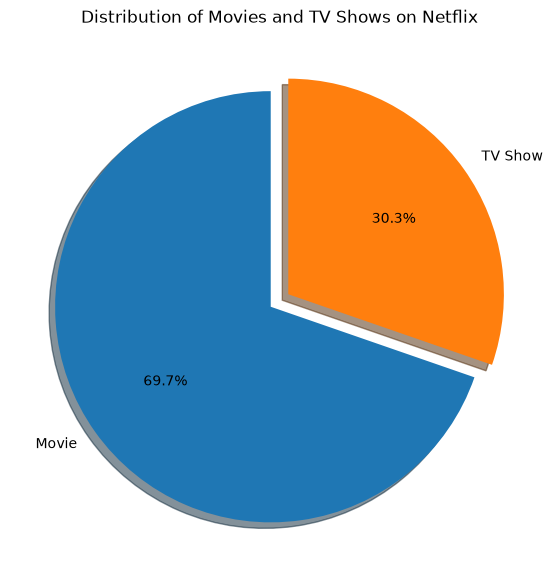

In [27]:
# Count Movies and TV Shows
type_count = df['type'].value_counts()
# Create Pie Chart
 
plt.figure(figsize=(7,7))

plt.pie(
    type_count,
    labels=type_count.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0.05),
    shadow=True
)

plt.title("Movies and TV Shows on Netflix")
plt.title("Distribution of Movies and TV Shows on Netflix")
plt.savefig("movies_vs_tvshows_piechart.png")
plt.show()
